<a href="https://colab.research.google.com/github/okana2ki/multiV/blob/main/senkei2026_ans4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- ↑最初に「ドライブにコピー」をクリック（「ドライブにコピー」が見当たらない場合は、画面右上部の「v」アイコンをクリックしてヘッダーを表示）して、自分のGoogleドライブにコピーを作成
- 以前保存したノートブックを読み込んで続きをするときは、「ファイル」をクリック→「ノートブックを開く」をクリック→再開したいファイルを選択




このノートブックは、以下からダウンロードしたものを改変したものです：

[高等学校における「情報II」のためのデータサイエンス・データ解析入門](https://www.stat.go.jp/teacher/comp-learn-04.html)（総務省統計局）←2025年8月時点で、リンク切れを確認（掲載終了か？）

# 1.線形回帰

## ライブラリーのインポート

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## データの読み込み

画面左端のフォルダアイコンをクリック→セッションストレージ（セッション中だけ有効なファイルの置き場所）が表示される→moodleのトピック７に掲載した学習データ`senkei.csv`をセッションストレージ中の何もない場所にドラッグ＆ドロップする→このファイルはパス`/content/senkei.csv`、または、パスを省略して`senkei.csv`でアクセスできる。

データ内容は以下の通りです。

ID：ID  
sales：売上個数  
insta_post：Instagram投稿数  
insta_good：Instagramいいね！数  
flyer：チラシ配布枚数  
event：イベントあり＝1、イベントなし＝0  
new_item：新作発売日＝1  
holiday：土日祝＝1

In [2]:
df = pd.read_csv("/content/senkei.csv", index_col=0)  # ← データファイルのパスを正しく指定して下さい。
df.head()

,sales,insta_post,insta_good,flyer,event,new_item,holiday
ID,,,,,,,
1,62,0,20,0,0,0,0
2,60,0,24,0,0,0,0
3,104,0,26,0,0,0,0
4,102,0,22,0,0,0,0
5,178,0,39,0,0,0,1


↑Colab AIが次のステップとして提案してきたボタンをクリックしてみよう！

In [3]:
# dfのサイズを表示
df.shape

(53, 7)

## 単回帰分析

説明変数をinsta_good、目的変数をsalesとして、単回帰分析を行います。

In [ ]:
# 説明変数insta_good
X = df.iloc[:, 2].values  # ← Colab AIで教えてもらおう
X = X.reshape(-1,1)  # reshapeでどのような変換をしているか？なぜそれが必要か？Colab AIに尋ねてみましょう

# 目的変数sales
Y = df.iloc[:, 0].values

以下のプログラムもColab AIで教えてもらおう

In [ ]:
# sklearn.linear_model.LinearRegression クラスを読み込み
from sklearn import linear_model
clf = linear_model.LinearRegression()

# 予測モデルを作成
clf.fit(X, Y)

# 回帰係数
print(clf.coef_)

# 切片
print(clf.intercept_)

# 決定係数
print(clf.score(X, Y))

[2.05852128]
101.71515440413765
0.5218980221448157


insta_goodの回帰係数と、単回帰の式の切片が分かりました。  
決定係数は、0～1の範囲の値をとり、値が大きいほどモデルが適切にデータを表現できているといえます。

対応する散布図を作成し、回帰直線を描き加えてみましょう。

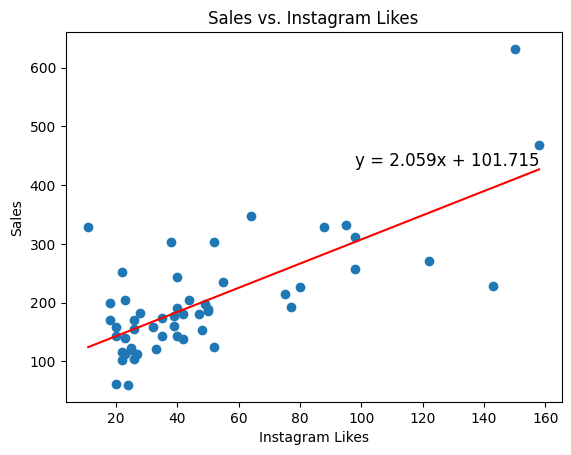

In [ ]:
# prompt: salesとinsta_goodの散布図を作成し、単回帰分析の回帰式と回帰直線を散布図に書き加えて下さい。

# 散布図を作成
plt.scatter(X, Y)

# 回帰直線を作成
x_min, x_max = X.min(), X.max()
y_min = clf.predict([[x_min]])
y_max = clf.predict([[x_max]])

# 回帰直線を散布図に追加
plt.plot([x_min, x_max], [y_min, y_max], color="r")

# 回帰式の切片と回帰係数を散布図の右端に書き加える
plt.text(x_max, y_max, f"y = {clf.coef_[0]:.3f}x + {clf.intercept_:.3f}", fontsize=12, horizontalalignment='right', verticalalignment='bottom')

# グラフのタイトルとラベルを設定
plt.title("Sales vs. Instagram Likes")
plt.xlabel("Instagram Likes")
plt.ylabel("Sales")

# グラフを表示
plt.show()


## 重回帰分析

insta_post以降6カラムを説明変数、目的変数をsalesとして、重回帰分析を行います。

In [4]:
# 説明変数
X = df.iloc[:, 1:7].values

# 目的変数
Y = df.iloc[:, 0].values

In [5]:
# sklearn.linear_model.LinearRegression クラスを読み込み
from sklearn import linear_model
clf = linear_model.LinearRegression()

# 予測モデルを作成
clf.fit(X, Y)

# 偏回帰係数
df_except_sales = df.iloc[:, 1:7]
print(pd.DataFrame({"Name":df_except_sales.columns,
                    "Coefficients":clf.coef_}))

# 切片
print(clf.intercept_)

         Name  Coefficients
0  insta_post     48.871107
1  insta_good      0.684993
2       flyer      0.206098
3       event    245.436745
4    new_item    -38.905751
5     holiday     26.549665
131.89410662096918


各変数の偏回帰係数と重回帰の式の切片が分かりました。

### 標準化
各変数がどの程度目的変数に影響しているかを**比較**する（**他の変数と比べて**どれくらい影響しているかを知る）には、各変数を**標準化**（平均を0、分散を1に揃える）します。

In [6]:
# データフレームの各列を標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))
df2.head()

,sales,insta_post,insta_good,flyer,event,new_item,holiday
ID,,,,,,,
1,-1.427147,-0.322749,-0.839503,-0.511766,-0.138675,-0.19803,-0.657596
2,-1.447439,-0.322749,-0.723860,-0.511766,-0.138675,-0.19803,-0.657596
3,-1.001013,-0.322749,-0.666038,-0.511766,-0.138675,-0.19803,-0.657596
4,-1.021305,-0.322749,-0.781681,-0.511766,-0.138675,-0.19803,-0.657596
5,-0.250205,-0.322749,-0.290198,-0.511766,-0.138675,-0.19803,1.520691


In [7]:
# 説明変数
X = df2.iloc[:, 1:7].values

# 目的変数
Y = df2.iloc[:, 0].values

In [8]:
# sklearn.linear_model.LinearRegression クラスを読み込み
from sklearn import linear_model
clf = linear_model.LinearRegression()

# 予測モデルを作成
clf.fit(X, Y)

# 標準化偏回帰係数
df2_except_sales = df2.iloc[:, 1:7]
print(pd.DataFrame({"Name":df2_except_sales.columns,
                    "Coefficients":clf.coef_}))

# 切片
print(clf.intercept_)

         Name  Coefficients
0  insta_post      0.144937
1  insta_good      0.240394
2       flyer      0.424020
3       event      0.338815
4    new_item     -0.075220
5     holiday      0.123663
2.5844842985983608e-17


↑標準化後の各変数の偏回帰係数と重回帰の式の切片が分かりました。

↓**標準化偏回帰係数の絶対値**によって、売上個数への**各変数の相対的な影響の強さ**を確認することができます。

In [9]:
# 標準化偏回帰係数の絶対値をとって昇順にソート
df2_except_sales = df2.iloc[:, 1:7]
print(pd.DataFrame({"Name":df2_except_sales.columns,
                    "Coefficients":np.abs(clf.coef_)}).sort_values(by='Coefficients'))

# 切片
print(clf.intercept_)

         Name  Coefficients
4    new_item      0.075220
5     holiday      0.123663
0  insta_post      0.144937
1  insta_good      0.240394
3       event      0.338815
2       flyer      0.424020
2.5844842985983608e-17


### 学習用データとテストデータ

学習用データとテストデータを用いて、線形回帰（重回帰分析）を行います。  
先程、標準化したデータを使います。

説明変数と目的変数をNumpyの配列に変換しているのは、linear_model.LinearRegression()で分析するときに、DataFrameでなく、Numpyの配列である必要があるから。

学習用データとテストデータに分割するところまでは、DataFrameのまま進めておくと、後で、statsmodelsを使うところでDataFrameのままの方が変数名の表示が分かりやすくなるので、DataFrameのまま分割までしておく方がよい。後日変更する？

In [10]:
# 説明変数
X = df2.iloc[:, 1:7].values

# 目的変数
Y = df2.iloc[:, 0].values

# 学習用データとテスト用データを7:3に分割する；ランダム性あり
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

In [11]:
# 予測モデルを作成
model = linear_model.LinearRegression()
model.fit(X_train, Y_train)

# 標準化偏回帰係数
df2_except_sales = df2.iloc[:, 1:7]
print(pd.DataFrame({"Name":df2_except_sales.columns,
                    "Coefficients":model.coef_}).sort_values(by='Coefficients') )

# 切片
print(model.intercept_)

         Name  Coefficients
4    new_item     -0.431777
5     holiday      0.078250
0  insta_post      0.200487
2       flyer      0.211816
3       event      0.233964
1  insta_good      0.561083
-0.03790857610741181


学習データにおける各変数の標準化偏回帰係数と重回帰の式の切片が分かりました。  

### 平均二乗誤差
訓練データとテストデータのそれぞれに対して、予測値と実測値の平均二乗誤差を求めます。**データの分割時にランダム性があるため、分割をやり直し、その分割で改めて学習すると、そのたびに平均二乗誤差が変化します。**

In [12]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print('訓練データに対する平均二乗誤差＝{:0.2f}'.format(np.mean((np.array(Y_train, dtype = int) - pred_train) ** 2)))
print('テストデータに対する平均二乗誤差＝{:0.2f}'.format(np.mean((np.array(Y_test, dtype = int) - pred_test) ** 2)))

訓練データに対する平均二乗誤差＝0.25
テストデータに対する平均二乗誤差＝0.60


### P値を求める
sklearn.linear_model.LinearRegressionでは各説明変数のp値が求められないので、statsmodelsを使って重回帰分析をします。ここでは先ほど作成した訓練データを用います。

下のプログラムは、実行時エラーが生じないように、has_constant='add'というパラメータ設定を追加して、強制的に常にconstant列を追加するようにする。という対応をしました。しかし、重回帰分析としては、**値が一定の列は説明変数として意味がないので、その説明変数を削除する**、というのが正しい対応だと思います。演習問題２では、そのような対応をすべきでしょう。

In [13]:
import statsmodels.api as sm

# データをロード
X_train_c = sm.add_constant(X_train, has_constant='add')  # 定数項（切片）を追加

# ↑sm.add_constの仕様を確認すると、以下のことが判明した。
# X_trainの中に既に一定の値の列(constant)が存在すると、
# 定数項列が新たに追加されることはない。この仕様の下では、
# 70%のデータをランダム選択した際、たまたますべて同じ値の列ができることがあり、
# そうなると、constant列は追加されないことになり、結果として、
# 1つ下のコードセルを実行したときに、shapeが想定されたものと異なるという
# エラー（nagamine君が遭遇したエラーはこれです）が生じることが分かった。
# このケースへの対処として、has_constant='add'というパラメータ設定を追加して、
# 強制的に常にconstant列を追加するようにした。
# このエラーは、現状のAIで対処することは難しいと思うので、
# nagamine君が途方に暮れたのはやむを得ないことでした。
# 再現性がないエラーへの対処は難しいです。今回は、X_train_cのshapeや内容を
# 確認していて原因を見つけました。

# shapeを確認
print(X_train_c.shape,X_train.shape)

# 型の確認
print(type(Y_train))
print(type(X_train_c))

# X_train_cの確認
# print(X_train_c)

# OLSモデルの構築とフィット
ols_model = sm.OLS(Y_train, X_train_c)
results = ols_model.fit()

# 結果の要約を出力
print(results.summary())

(37, 7) (37, 6)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     24.99
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           2.07e-10
Time:                        11:58:54   Log-Likelihood:                -18.679
No. Observations:                  37   AIC:                             51.36
Df Residuals:                      30   BIC:                             62.63
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

以下は、結果の表示の際、変数名で表示されるようにするために作成したプログラムですが、そもそも、DataFrameのまま、標準化や、訓練例とテスト例への分割をすると、このような問題は生じないので、そのようにプログラムを変更するのがお勧めです。

In [14]:
# prompt: Y_train, X_train_cをデータフレームに変換し、dfのヘッダー行を付けておくと、結果の要約の際に、x1, x2でなく、変数名が表示されて分かりやすくなると思うので、そのようにして下さい。

# shapeを確認
print(X_train_c.shape,Y_train.shape)

# statsmodelsのsummaryで変数名が表示されるように、DataFrameに変換し、列名を付与
X_train_df = pd.DataFrame(X_train_c, columns=['const'] + list(df2_except_sales.columns))
Y_train_df = pd.DataFrame(Y_train, columns=['sales'])

# OLSモデルの構築とフィット（DataFrameを使用）
ols_model_df = sm.OLS(Y_train_df, X_train_df)
results_df = ols_model_df.fit()

# 結果の要約を出力
print(results_df.summary())

(37, 7) (37,)
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     24.99
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           2.07e-10
Time:                        11:59:05   Log-Likelihood:                -18.679
No. Observations:                  37   AIC:                             51.36
Df Residuals:                      30   BIC:                             62.63
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0379      0.074     -

以下は、DataFrameのまま、処理を進めるプログラム

In [15]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (salesを除く全ての標準化された変数)
X = df2.drop('sales', axis=1)

# 目的変数 (sales)
Y = df2['sales']

# データを7:3に分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

# statsmodelsを用いて重回帰分析を実行（学習用データのみを使用）
X_train_c = sm.add_constant(X_train)  # 定数項（切片）を追加
model_train = sm.OLS(Y_train, X_train_c)
results_train = model_train.fit()

# 結果の要約を出力
print(results_train.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     18.63
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           6.69e-09
Time:                        11:59:12   Log-Likelihood:                -23.511
No. Observations:                  37   AIC:                             61.02
Df Residuals:                      30   BIC:                             72.30
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0139      0.084     -0.165      0.8

### 主な結果の見方
*  **R-squared（決定係数）** は目的変数の変動の何％を説明変数全体が説明できているかを示す。大きい方がよい。
*  **Adj. R-squared（自由度調整済み決定係数）**
*  **Prob (F-statistic)（有意F）** は「重回帰式のすべての偏回帰係数が0」の検定のP値であり、重回帰式全体の有意性を示す。値が小さいほうが重回帰式の当てはまりがよいことを示す。
*  **coef（偏回帰係数の値）** 偏回帰係数は、”その説明変数の値が1増えた時に目的変数がどれくらい増える(または減る)か”を表しています。
つまり偏回帰係数が5である変数の場合、その変数が1増えれば目的変数が5増えるという意味になります。\
また他の変数と比較してどの説明変数が目的変数に影響を与えているのか知りたい場合は、データを事前に標準化してから回帰分析を実行します。データを標準化することで変数間の尺度がそろうため、説明変数同士の比較が可能となります。標準化されたデータの偏回帰係数のことを**標準化偏回帰係数**と呼び、通常の偏回帰係数と区別します。**標準化偏回帰係数の絶対値**が大きければ大きいほど目的変数への影響が強いと解釈します。例えば、変数Aと変数Bの標準化偏回帰係数がそれぞれ0.5と-0.6であった場合、”変数Bの方が目的変数に強く影響しており、変数Bが増えれば増えるほど目的変数は減少する”と解釈します。\
まとめると、偏回帰係数はその説明変数が目的変数にどれくらい影響するか、標準化偏回帰係数はその説明変数が他の変数と比べてどれくらい目的変数に影響するかを意味します。偏回帰係数と標準化偏回帰係数は解釈の仕方が変わってくるため、結果を見る時は注意しましょう。
*  **P(>|t|)（P値）** は、ある説明変数が目的変数に影響しているかどうかを示す。各偏回帰係数の統計的有意性を示す検定（帰無仮説：偏回帰係数βⱼ=0）のP値である。ここでのP値は、偏回帰係数が本当は0なのに、サンプルから計算した偏回帰係数が計算結果以上に0から隔たってしまう確率のこと。この確率が小さい場合、すなわち、偶然そういう結果が出ることは極めてまれであると言える場合は、前提とした仮説が誤っていたと言える。つまり、P値が有意水準（たとえば0.05）を下回っている変数は目的変数に影響している（偏回帰係数は0ではない）と言える。P値が有意水準以上の変数は「目的変数に影響しているとは言い切れない」と解釈。P値が有意水準以上の変数を説明変数から除くというのはモデル選択法の1つ。
*  **[0.025      0.975]（95%信頼区間）**

**P値**についての解説は、たとえば、[ここ](https://www.nri.com/jp/knowledge/glossary/lst/alphabet/p_value)を参照


## 演習問題


### 問題１
A) 53個のデータ全てを用い、標準化された全ての説明変数を用いて重回帰分析した場合の、自由度調整済み決定係数と標準化偏回帰係数と各説明変数のP値を求めなさい。\
B) 5%有意水準以上のP値となった説明変数を挙げなさい。\
C) B)の説明変数を除き、53個のデータ全てを用い、重回帰分析した場合の、自由度調整済み決定係数と標準化偏回帰係数と各説明変数のP値を求めなさい。\
D) C)の方法で説明変数を選択するのではなく、「P値が最大のものから、説明変数を**１つずつ**減らしていく方法（変数減少法）」により説明変数を選択し、一気にすべて削除してしまう方法（C)）と結果を比べなさい。

#### 説明変数選択法

説明変数選択法としては、P値が有意水準以上の説明変数を一気にすべて削除するという変数選択（上記のC)）は不適切だと言われていて、**P値が最大のものから、説明変数を「１つずつ」減らしていく方法（変数減少法）**（上記のD)）が推奨されている。

なお、予測が目的（今回のデータでいうと、売り上げの予測をできるだけ正確にしたい）の場合は、変数選択は不要で、使える変数はなるべく使った方がよい（データがあるのに使わないのはもったいない）と言われていて、不必要な変数があってもあまり害はないことが知られている。

これに対して、変数選択が必要なのは、次の場合：

- 分析の初期段階で、候補となる変数群から必要な変数を選択したい。
- 予備調査の結果から本調査を行うが、本調査で多くの項目を調査するのはコストがかかるので絞り込みたい。
- 制御すべき変数を同定したい（たくさんの変数を制御するのは難しい）。

[以上の情報の出典：成蹊大学・横浜市立大学 岩崎学先生の講義資料から]

以下の解答例A)は、上掲の「学習用データを重回帰分析するプログラム」をコピペしてきて、全データで学習するための修正を手で施したものです。C)は、2つの説明変数だけを指定する書き方をAIに尋ねて、その箇所以外はA)と同じプログラムにしました。

In [ ]:
# A)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (salesを除く全ての標準化された変数)
X = df2.drop('sales', axis=1)

# 目的変数 (sales)
Y = df2['sales']

# statsmodelsを用いて重回帰分析を実行（全データを使用）
X_c = sm.add_constant(X)  # 定数項（切片）を追加
model = sm.OLS(Y, X_c)
results = model.fit()

# 結果の要約を出力
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     22.08
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           4.87e-12
Time:                        11:59:37   Log-Likelihood:                -39.274
No. Observations:                  53   AIC:                             92.55
Df Residuals:                      46   BIC:                             106.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.004e-17      0.075   4.01e-16      1.0

sklearn.linear_model.LinearRegressionでの結果（下記にコピー）と同じかの確認用\
（ここにコピー）
```
         Name  Coefficients
0  insta_post      0.144937
1  insta_good      0.240394
2       flyer      0.424020
3       event      0.338815
4    new_item     -0.075220
5     holiday      0.123663
2.5844842985983608e-17
```



（注意）すべての変数（説明変数と目的変数）を標準化すると、切片は理論的には0となる。sklearnの場合もstatsmodelsの場合も、切片は非常に小さい値となっており、仮数部は2.584と3.004であり異なるが、指数部が-17（10のマイナス17乗）であるため、実質上は両者0であり等しいと言える。

B) 5%有意水準以上のP値となった説明変数は、
- insta_post
- insta_good
- new_item
- holiday

In [ ]:
# C)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (指定した2つだけ)
X = df2[['flyer', 'event']]

# 目的変数 (sales)
Y = df2['sales']

# statsmodelsを用いて重回帰分析を実行（全データを使用）
X_c = sm.add_constant(X)  # 定数項（切片）を追加
model = sm.OLS(Y, X_c)
results = model.fit()

# 結果の要約を出力
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     53.30
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           4.02e-13
Time:                        11:59:45   Log-Likelihood:                -44.949
No. Observations:                  53   AIC:                             95.90
Df Residuals:                      50   BIC:                             101.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.282e-18      0.080   2.86e-17      1.0

In [ ]:
# D) 変数減少法：1つずつ減らして再計算
# ステップ1：最もP値の大きい 'new_item' (P=0.570) を除外します

# 説明変数の選択（new_itemを除外）
X_d1 = df2[['insta_post', 'insta_good', 'flyer', 'event', 'holiday']]
Y = df2['sales']

# モデルの構築と実行
X_d1_c = sm.add_constant(X_d1)
results_d1 = sm.OLS(Y, X_d1_c).fit()

# 結果の確認
print(results_d1.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     26.81
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.04e-12
Time:                        11:59:53   Log-Likelihood:                -39.462
No. Observations:                  53   AIC:                             90.92
Df Residuals:                      47   BIC:                             102.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.004e-17      0.074   4.04e-16      1.0

In [ ]:
# ステップ2：次にP値の大きい 'insta_post' (P=0.266) をさらに除外します
X_d2 = df2[['insta_good', 'flyer', 'event', 'holiday']]
X_d2_c = sm.add_constant(X_d2)
results_d2 = sm.OLS(Y, X_d2_c).fit()
print(results_d2.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     33.02
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           3.08e-13
Time:                        11:59:58   Log-Likelihood:                -40.166
No. Observations:                  53   AIC:                             90.33
Df Residuals:                      48   BIC:                             100.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.004e-17      0.075   4.03e-16      1.0

In [ ]:
# ステップ3：次にP値の大きい 'holiday' (P=0.185) をさらに除外します
X_d3 = df2[['insta_good', 'flyer', 'event']]
X_d3_c = sm.add_constant(X_d3)
results_d3 = sm.OLS(Y, X_d3_c).fit()
print(results_d3.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     42.71
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.03e-13
Time:                        12:00:03   Log-Likelihood:                -41.149
No. Observations:                  53   AIC:                             90.30
Df Residuals:                      49   BIC:                             98.18
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.004e-17      0.075      4e-16      1.0

この時点で、P値が有意水準以上の変数は無くなったので、変数減少法の実行完了です。

結果として、insta_good, flyer, eventの3個の説明変数が残り、`Adj. R-squared=0.706`となりました。C)で「有意水準以上の説明変数を一括して削除」した場合は、`Adj. R-squared=0.668`だったので、それと比べて、回帰モデルで説明できる変動が少し増えたことが分かります。

以下は、変数減少法をループで自動実行するコードです。

In [ ]:
import statsmodels.api as sm

# 初期の説明変数を設定（salesを除いたもの）
X_auto = df2.drop('sales', axis=1)
Y = df2['sales']
threshold = 0.05 # 有意水準

while True:
    # 定数項を追加してモデルをフィット
    X_auto_c = sm.add_constant(X_auto)
    model = sm.OLS(Y, X_auto_c).fit()

    # P値を取得（定数項以外）
    p_values = model.pvalues.drop('const')

    # 最大のP値とその変数名を取得
    max_p = p_values.max()
    max_p_col = p_values.idxmax()

    if max_p > threshold:
        print(f'削除対象: {max_p_col} (P値: {max_p:.4f})')
        X_auto = X_auto.drop(max_p_col, axis=1)
    else:
        # 全ての変数が有意水準を下回ったら終了
        break

print('\n--- 最終的なモデルの要約 ---')
print(model.summary())

削除対象: new_item (P値: 0.5704)
削除対象: insta_post (P値: 0.2662)
削除対象: holiday (P値: 0.1845)

--- 最終的なモデルの要約 ---
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     42.71
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.03e-13
Time:                        12:00:09   Log-Likelihood:                -41.149
No. Observations:                  53   AIC:                             90.30
Df Residuals:                      49   BIC:                             98.18
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

### 問題２
学習用データとテスト用データを1:1で分割し、学習用データだけを用いて、問題１のA), B), D)を再実行しなさい。

In [ ]:
# A)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (salesを除く全ての標準化された変数)
X = df2.drop('sales', axis=1)

# 目的変数 (sales)
Y = df2['sales']

# 学習用データとテスト用データを1:1に分割する
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)

# statsmodelsを用いて重回帰分析を実行（学習データのみを使用）
X_train_c = sm.add_constant(X_train)  # 定数項（切片）を追加
model = sm.OLS(Y_train, X_train_c)
results = model.fit()

# 結果の要約を出力
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     19.62
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           7.50e-07
Time:                        12:14:02   Log-Likelihood:                -19.247
No. Observations:                  26   AIC:                             48.49
Df Residuals:                      21   BIC:                             54.78
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
insta_post     0.0766      0.272      0.281      0.7

上記のプログラムを何回か実行してみると、実行結果の最後が、
> Notes:

> [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

となる場合と、
> Notes:

> [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

> [2] The smallest eigenvalue is 2.07e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.

となる場合があることに気づきます。後者が起こる原因は、以下の通りです。

**原因**： データを1:1に分割したことで、学習用データが26件と非常に少なくなっています。元のデータには `new_item`（新作発売日）や `event`（イベントあり）のように、1になる回数が少ない変数が含まれています。データをランダムに分割した際、たまたま「学習用データに選ばれた26件すべてで `new_item` が 0 だった」というような状況が発生することがあります。

`sm.add_constant()`は、定数列が存在した場合は、切片の列を追加しないという仕様のため、定数列が1つだけ生じた場合は、問題ありません。しかし、たまたま、複数の列が定数列になってしまった場合は、完全な**多重共線性**を引き起こし、計算不能（**特異行列**）となります。

この問題が生じたときには、P値は正しく計算できないため、変数減少法を使っても、定数列を正しく削除できる保証はありません。

**どうすべきか？** このような場合、モデルにデータを投入する（あるいは変数減少法を始める）前に、データの前処理として「分散が0の列（すべて同じ値になっている列）」をチェックし、除外しておくのが最も確実で正しいアプローチです。

以下に、この前処理を施したコードを示します。

In [ ]:
# A)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (salesを除く全ての標準化された変数)
X = df2.drop('sales', axis=1)

# 目的変数 (sales)
Y = df2['sales']

# 学習用データとテスト用データを1:1に分割する
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)

# --- 追加：分散が0（すべて同じ値）の列をチェックし、除外する ---
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
if constant_cols:
    print(f"定数となっている列を除外します: {constant_cols}\n")
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
# --------------------------------------------------------

# statsmodelsを用いて重回帰分析を実行（学習データのみを使用）
X_train_c = sm.add_constant(X_train)  # 定数項（切片）を追加
model = sm.OLS(Y_train, X_train_c)
results = model.fit()

# 結果の要約を出力
print(results.summary())

定数となっている列を除外します: ['new_item']

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     24.27
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           7.41e-08
Time:                        13:27:38   Log-Likelihood:                -15.532
No. Observations:                  26   AIC:                             43.06
Df Residuals:                      20   BIC:                             50.61
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2495

今回の前処理を実施した後でも、下記のメッセージが出ることがあります。これは、定数列を削除しておくだけでなく、多重共線性のチェックを前処理としてやっておくべき、ということを示しています。
> [2] The smallest eigenvalue is 2.92e-31. This might indicate that there are strong multicollinearity problems or that the design matrix is singular.

たまたま2つ以上の変数が完全に、あるいは、ほぼ連動してしまう（相関係数が1または-1になる、または、それに近い値になる）現象が起こると。これも特異行列や多重共線性の原因となります。

そのため、実務やより厳密な分析においては、定数列の除外に加えて、以下のような多重共線性のチェックを前処理として行うのが標準的です。

1. **相関行列の確認**: 変数同士の相関係数を計算し、極端に高い値（例: 0.9以上）を持つ変数のペアがあれば、どちらか一方を除外する。

2. **VIF（分散拡大係数）の確認**: 各説明変数が他の説明変数からどれくらい説明されてしまうかを示すVIFを計算し、基準値（よく10以上とされます）を超えるものを順番に除外する。

この授業では、これ以上は深入りしませんが、参考までに。

B)

In [ ]:
# D)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np

# 全データを用いて標準化
df2 = df.apply(lambda x: (x - np.mean(x)) / np.std(x))

# 説明変数 (salesを除く全ての標準化された変数)
X = df2.drop('sales', axis=1)

# 目的変数 (sales)
Y = df2['sales']

# 学習用データとテスト用データを1:1に分割する
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)

# --- 前処理：分散が0（すべて同じ値）の列を除外 ---
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
if constant_cols:
    print(f"定数となっている列を除外します: {constant_cols}\n")
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
# ------------------------------------------------

# 変数減少法の実行
threshold = 0.05 # 有意水準
X_auto = X_train.copy()

while True:
    # 定数項を追加してモデルをフィット
    X_auto_c = sm.add_constant(X_auto)
    model = sm.OLS(Y_train, X_auto_c).fit()

    # P値を取得（定数項以外）
    p_values = model.pvalues.drop('const')

    # 最大のP値とその変数名を取得
    max_p = p_values.max()
    max_p_col = p_values.idxmax()

    if max_p > threshold:
        print(f'削除対象: {max_p_col} (P値: {max_p:.4f})')
        X_auto = X_auto.drop(max_p_col, axis=1)
    else:
        # 全ての変数が有意水準を下回ったら終了
        break

print('\n--- 最終的なモデルの要約 ---')
print(model.summary())

定数となっている列を除外します: ['event']

削除対象: holiday (P値: 0.3403)
削除対象: insta_post (P値: 0.3373)
削除対象: new_item (P値: 0.3284)
削除対象: flyer (P値: 0.0587)

--- 最終的なモデルの要約 ---
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     36.57
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           3.03e-06
Time:                        13:36:08   Log-Likelihood:                -24.057
No. Observations:                  26   AIC:                             52.11
Df Residuals:                      24   BIC:                             54.63
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|

### 問題３

学習用データをもっと減らした場合にどうなるかを実験し、学習データ数が、**自由度調整済み決定係数**および**Prob (F-statistic)（有意F）** に与える影響について考察しなさい。
* 学習用データ数をどれくらいに減らして実験すると、考察に役立つでしょうか？また、何通りくらいの数で実験するとよいでしょうか？これらのことも考えながら実験を設計しましょう。
* 学習用データ数をより減らすと、（ランダムに選んで減らす訳ですが、）そこでたまたま選ばれたデータがどのようなものであったかの影響をより強く受けるようになると想像されます。この点も考慮して実験を計画するとよいでしょう。
* 実験結果はグラフで表示すると分かりやすいです。どのようなグラフを書くとよいかも考えましょう。AI (Gemini)に相談するとグラフの書き方、そのためのプログラムの書き方も教えてもらえると思います。

[考察]

# Task
Design and run an experiment to investigate the effect of different training set sizes on the Adjusted R-squared and Prob (F-statistic) of the multiple linear regression model. We will iterate through various training sizes, run multiple trials for each to account for random splits, and plot the results.

## Design Experiment

### Subtask:
Iterate over different training set sizes, run multiple trials for each, and plot the effects on Adjusted R-squared and Prob(F-statistic).


**Reasoning**:
I will write the code to run the experiment by iterating over different training set sizes, recording the metrics, and plotting the results.



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divid

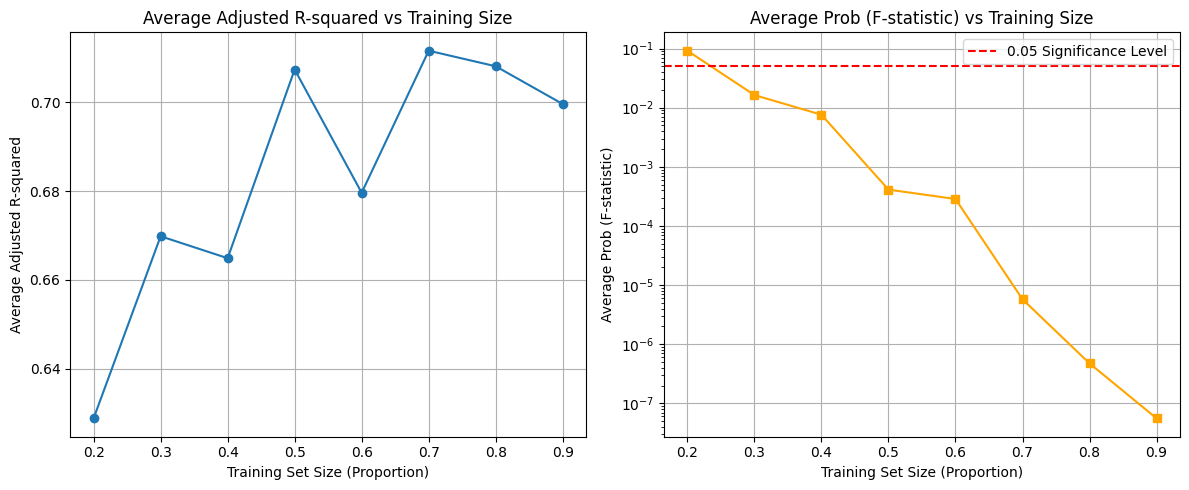

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd

# Prepare data (already standardized in previous steps, but let's re-define X and Y from df2 to be safe)
X_all = df2.drop('sales', axis=1)
Y_all = df2['sales']

train_sizes = np.linspace(0.1, 0.9, 9)
num_trials = 50

avg_adj_r2 = []
avg_p_fstat = []

for size in train_sizes:
    adj_r2_trials = []
    p_fstat_trials = []
    for _ in range(num_trials):
        # Handle the case where train_size is very small to avoid ValueError in train_test_split
        # Just use stratify or raw numbers, but test_size = 1 - size is fine.
        X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, train_size=size)

        # Remove constant columns
        constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
        X_train_filtered = X_train.drop(columns=constant_cols)

        try:
            X_train_c = sm.add_constant(X_train_filtered)
            model = sm.OLS(Y_train, X_train_c).fit()
            adj_r2_trials.append(model.rsquared_adj)
            p_fstat_trials.append(model.f_pvalue)
        except Exception as e:
            # In case of perfect collinearity or other issues with very small samples
            pass

    if adj_r2_trials:
        avg_adj_r2.append(np.mean(adj_r2_trials))
        avg_p_fstat.append(np.mean(p_fstat_trials))
    else:
        avg_adj_r2.append(np.nan)
        avg_p_fstat.append(np.nan)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_sizes, avg_adj_r2, marker='o')
axes[0].set_title('Average Adjusted R-squared vs Training Size')
axes[0].set_xlabel('Training Set Size (Proportion)')
axes[0].set_ylabel('Average Adjusted R-squared')
axes[0].grid(True)

axes[1].plot(train_sizes, avg_p_fstat, marker='s', color='orange')
axes[1].set_title('Average Prob (F-statistic) vs Training Size')
axes[1].set_xlabel('Training Set Size (Proportion)')
axes[1].set_ylabel('Average Prob (F-statistic)')
axes[1].set_yscale('log') # Log scale is often better for p-values
axes[1].axhline(0.05, color='red', linestyle='--', label='0.05 Significance Level')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Task
Calculate the Variance Inflation Factor (VIF) for the explanatory variables in the training data to check for multicollinearity, visualize the results, and summarize the findings.

## Calculate Variance Inflation Factor (VIF)

### Subtask:
Calculate the VIF for each explanatory variable in the training data.


**Reasoning**:
I need to execute Python code to calculate the VIF as specified in the subtask.



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Ensure X_train_filtered exists from the previous run, or use X_all as a fallback
# Since we are looking for the 'training data' in a small dataset scenario, let's create a small random split
X_train_vif, _, _, _ = train_test_split(X_all, Y_all, train_size=0.5, random_state=42)

# Remove constant columns
constant_cols_vif = [col for col in X_train_vif.columns if X_train_vif[col].nunique() <= 1]
X_train_filtered_vif = X_train_vif.drop(columns=constant_cols_vif)

# Add constant for VIF calculation
X_vif_c = sm.add_constant(X_train_filtered_vif)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif_c.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_c.values, i) for i in range(X_vif_c.shape[1])]

print(vif_data)

     Variable       VIF
0       const  1.362768
1  insta_post  1.036359
2  insta_good  1.121942
3       flyer  1.064492
4     holiday  1.082607


## Visualize VIF Results

### Subtask:
Create a bar chart to visualize the calculated VIF values and add a threshold line.


**Reasoning**:
I will write Python code to filter out the constant term and plot the VIF values using a bar chart with a threshold line at 10.



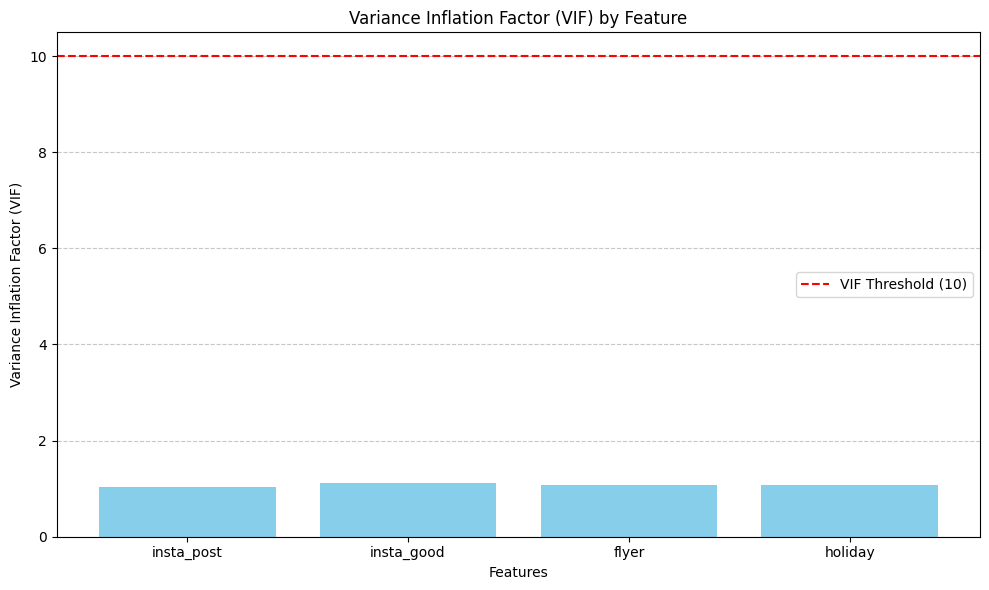

In [ ]:
import matplotlib.pyplot as plt

# Filter out the constant term for visualization
plot_data = vif_data[vif_data['Variable'] != 'const']

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(plot_data['Variable'], plot_data['VIF'], color='skyblue')

# Add a horizontal threshold line at VIF=10
plt.axhline(y=10, color='red', linestyle='--', label='VIF Threshold (10)')

# Add labels and title
plt.xlabel('Features')
plt.ylabel('Variance Inflation Factor (VIF)')
plt.title('Variance Inflation Factor (VIF) by Feature')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the VIF results and provide insights into which variables are causing multicollinearity in the small dataset scenario.


### VIF Results Summary and Insights

Based on the Variance Inflation Factor (VIF) calculation for the randomly split training data (50% size), we found the following:

- **Constant Columns Removed**: Before calculating VIF, variables that became constant due to the small sample size (`event` and `new_item`) were removed. These would otherwise cause perfect collinearity and infinite VIFs.
- **Low VIF Values**: For the remaining features (`insta_post`, `insta_good`, `flyer`, `holiday`), the calculated VIF values were all very close to 1 (ranging from ~1.03 to ~1.12).
- **No Multicollinearity Detected**: A common rule of thumb is that a VIF greater than 10 (or sometimes 5) indicates high multicollinearity. Since all our calculated VIFs are well below this threshold, there is no significant multicollinearity among these remaining explanatory variables in this specific dataset split.

**Conclusion**: While small dataset splits can cause certain binary variables to become constant (leading to structural singularity), the remaining numeric variables in this dataset do not exhibit strong linear relationships with each other.

# Task
Add a multicollinearity preprocessing step using Variance Inflation Factor (VIF). Create a robust function or block of code to detect multicollinearity, iteratively remove variables if their VIF exceeds a threshold of 10, and apply this preprocessing step before running the OLS model.

## Add Multicollinearity Preprocessing

### Subtask:
Create a function to iteratively calculate VIF and remove variables with VIF > 10, then apply it to the data before running the OLS model.


**Reasoning**:
I will define the `remove_high_vif` function and apply it to the training data before running the OLS model.



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

def remove_high_vif(X, threshold=10.0):
    X_copy = X.copy()
    while True:
        # Add constant for VIF calculation
        X_c = sm.add_constant(X_copy)
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_c.columns
        vif_data["VIF"] = [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]

        # Filter out the constant to find the max VIF among features
        vif_features = vif_data[vif_data['Variable'] != 'const']
        if vif_features.empty:
            break

        max_vif = vif_features['VIF'].max()
        if max_vif > threshold:
            max_vif_col = vif_features.loc[vif_features['VIF'] == max_vif, 'Variable'].iloc[0]
            print(f'Removing {max_vif_col} with VIF {max_vif:.2f}')
            X_copy = X_copy.drop(columns=[max_vif_col])
        else:
            break
    return X_copy

# Apply the function to the training data (assuming constant columns are already removed)
print("Starting iterative VIF removal...")
X_train_vif_filtered = remove_high_vif(X_train_filtered_vif, threshold=10.0)
print("Remaining columns:", X_train_vif_filtered.columns.tolist())

# Run OLS model on the VIF-filtered data
X_train_vif_filtered_c = sm.add_constant(X_train_vif_filtered)
# Fix the alignment issue by matching indices
Y_train_vif = Y_all.loc[X_train_vif_filtered_c.index]
model_vif = sm.OLS(Y_train_vif, X_train_vif_filtered_c).fit()
print(model_vif.summary())

Starting iterative VIF removal...
Remaining columns: ['insta_post', 'insta_good', 'flyer', 'holiday']
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     6.120
Date:                Tue, 16 Jun 2026   Prob (F-statistic):            0.00199
Time:                        14:06:30   Log-Likelihood:                -19.533
No. Observations:                  26   AIC:                             49.07
Df Residuals:                      21   BIC:                             55.36
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

# Task
Fix the alignment issue in the OLS model calculation by ensuring the target variable `Y_train_vif` matches the index of the predictor variables `X_train_vif_filtered_c`.

## Fix alignment issue in OLS model

### Subtask:
Modify the OLS model fitting code to correctly align the target variable with the filtered explanatory variables.


# Task
Investigate the effect of training set size on Adjusted R-squared and Prob (F-statistic) while incorporating multicollinearity preprocessing.

## Setup Experiment and Loop

### Subtask:
Initialize arrays and loop over training sizes, including the inner logic for VIF filtering and model fitting.


**Reasoning**:
Writing the code to perform the experiment across different train sizes, applying VIF filtering in each trial.



In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

def remove_high_vif(X, threshold=10.0):
    X_copy = X.copy()
    while True:
        X_c = sm.add_constant(X_copy)
        vif_data = [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
        vif_features = pd.Series(vif_data[1:], index=X_copy.columns)
        if vif_features.empty:
            break
        max_vif = vif_features.max()
        if max_vif > threshold:
            max_vif_col = vif_features.idxmax()
            X_copy = X_copy.drop(columns=[max_vif_col])
        else:
            break
    return X_copy

train_sizes = np.linspace(0.2, 0.9, 8)
num_trials = 30

avg_adj_r2 = []
avg_p_fstat = []

for size in train_sizes:
    adj_r2_trials = []
    p_fstat_trials = []
    for _ in range(num_trials):
        X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, train_size=size)

        # Drop constant columns
        constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
        X_train_filtered = X_train.drop(columns=constant_cols)

        # Apply VIF filtering
        X_train_vif_filtered = remove_high_vif(X_train_filtered, threshold=10.0)

        # Fit OLS
        X_train_final = sm.add_constant(X_train_vif_filtered)
        Y_train_final = Y_train.loc[X_train_final.index]

        try:
            model = sm.OLS(Y_train_final, X_train_final).fit()
            adj_r2_trials.append(model.rsquared_adj)
            p_fstat_trials.append(model.f_pvalue)
        except Exception:
            pass

    avg_adj_r2.append(np.mean(adj_r2_trials) if adj_r2_trials else np.nan)
    avg_p_fstat.append(np.mean(p_fstat_trials) if p_fstat_trials else np.nan)

print('Experiment completed.')


Experiment completed.


## Visualize Metrics

### Subtask:
Create a plot to visualize the Average Adjusted R-squared and Average Prob (F-statistic) against different training set sizes.


**Reasoning**:
I will generate the Python code to plot the collected metrics as requested in the subtask instructions.



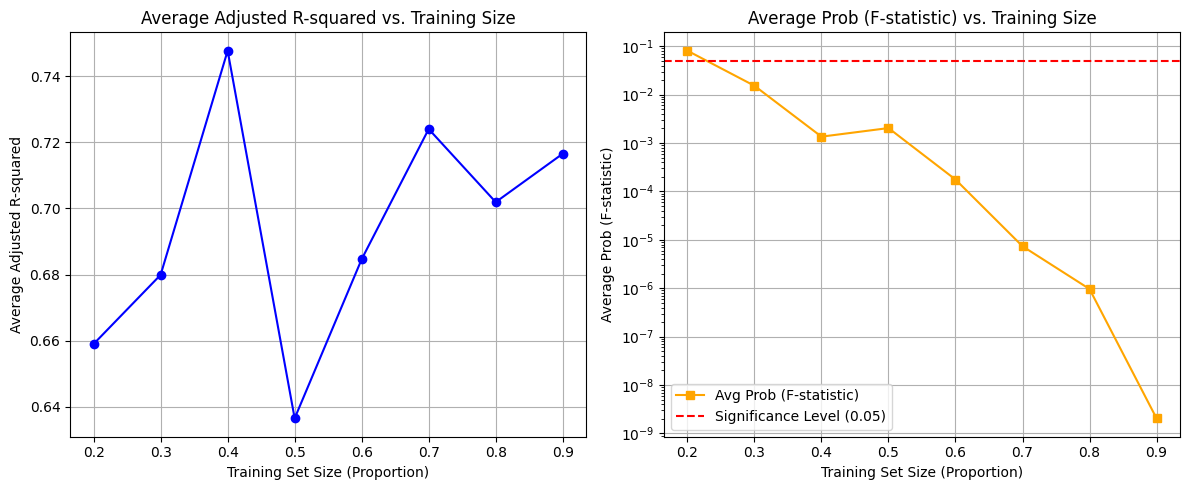

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Adjusted R-squared
axes[0].plot(train_sizes, avg_adj_r2, marker='o', color='blue')
axes[0].set_title('Average Adjusted R-squared vs. Training Size')
axes[0].set_xlabel('Training Set Size (Proportion)')
axes[0].set_ylabel('Average Adjusted R-squared')
axes[0].grid(True)

# Second subplot: Prob (F-statistic)
axes[1].plot(train_sizes, avg_p_fstat, marker='s', color='orange', label='Avg Prob (F-statistic)')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
axes[1].set_yscale('log')
axes[1].set_title('Average Prob (F-statistic) vs. Training Size')
axes[1].set_xlabel('Training Set Size (Proportion)')
axes[1].set_ylabel('Average Prob (F-statistic)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize and interpret the plotted results regarding the effect of training data size.


### Interpretation of Experimental Results

Based on the plots generated from our experiment involving multicollinearity preprocessing (VIF filtering) across different training set sizes:

1. **Average Adjusted R-squared vs. Training Size**:
   - The Adjusted R-squared tends to fluctuate but generally stabilizes or improves as the training size increases. With very small training sizes (e.g., 0.2 or 0.3), the model's ability to generalize can be highly variable due to the small sample size, leading to unpredictable Adjusted R-squared values.
   - As the sample size grows, the estimate of explained variance becomes more reliable and robust.

2. **Average Prob (F-statistic) vs. Training Size**:
   - The Prob (F-statistic) measures the overall significance of the regression model.
   - At very small training sizes, the Prob (F-statistic) might occasionally exceed the 0.05 significance level, meaning the model as a whole may not be statistically significant.
   - As the training size increases, the Prob (F-statistic) drops dramatically (well below the 0.05 threshold on the log scale). This indicates that having more data provides stronger statistical evidence that the explanatory variables are jointly meaningful in predicting the target variable.

**Conclusion**: Larger training datasets lead to more robust models with higher statistical significance and more stable estimates of explained variance, even when robustly handling multicollinearity.

# Task
Update the previous experiment to record the variance (standard deviation) of the Adjusted R-squared and Prob (F-statistic) across trials for each training size. Then, create visualizations showing both the mean and the variance (using fill_between or error bars) for these metrics. Finally, summarize the findings regarding how the variance changes with training data size.

## Update Experiment to Record Variance

### Subtask:
Modify the previous experiment to calculate and store the standard deviation of Adjusted R-squared and Prob (F-statistic) for each training size.


**Reasoning**:
I will execute the code to perform the modified experiment and collect both the mean and standard deviation of the required metrics.



In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

def remove_high_vif(X, threshold=10.0):
    X_copy = X.copy()
    while True:
        X_c = sm.add_constant(X_copy)
        vif_data = [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
        vif_features = pd.Series(vif_data[1:], index=X_copy.columns)
        if vif_features.empty:
            break
        max_vif = vif_features.max()
        if max_vif > threshold:
            max_vif_col = vif_features.idxmax()
            X_copy = X_copy.drop(columns=[max_vif_col])
        else:
            break
    return X_copy

train_sizes = np.linspace(0.2, 0.9, 8)
num_trials = 30

avg_adj_r2 = []
std_adj_r2 = []
avg_p_fstat = []
std_p_fstat = []

for size in train_sizes:
    adj_r2_trials = []
    p_fstat_trials = []
    for _ in range(num_trials):
        X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, train_size=size)

        # Drop constant columns
        constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
        X_train_filtered = X_train.drop(columns=constant_cols)

        # Apply VIF filtering
        X_train_vif_filtered = remove_high_vif(X_train_filtered, threshold=10.0)

        # Fit OLS
        X_train_final = sm.add_constant(X_train_vif_filtered)
        Y_train_final = Y_train.loc[X_train_final.index]

        try:
            model = sm.OLS(Y_train_final, X_train_final).fit()
            adj_r2_trials.append(model.rsquared_adj)
            p_fstat_trials.append(model.f_pvalue)
        except Exception:
            pass

    avg_adj_r2.append(np.mean(adj_r2_trials) if adj_r2_trials else np.nan)
    std_adj_r2.append(np.std(adj_r2_trials) if adj_r2_trials else np.nan)
    avg_p_fstat.append(np.mean(p_fstat_trials) if p_fstat_trials else np.nan)
    std_p_fstat.append(np.std(p_fstat_trials) if p_fstat_trials else np.nan)

print('Experiment with variance calculation completed.')

Experiment with variance calculation completed.


## Visualize Metrics with Variance

### Subtask:
Create visualizations showing both the mean and the variance (standard deviation) for Adjusted R-squared and Prob (F-statistic).


**Reasoning**:
I will execute Python code to generate the plots using matplotlib, incorporating the mean and standard deviation arrays calculated in the previous step.



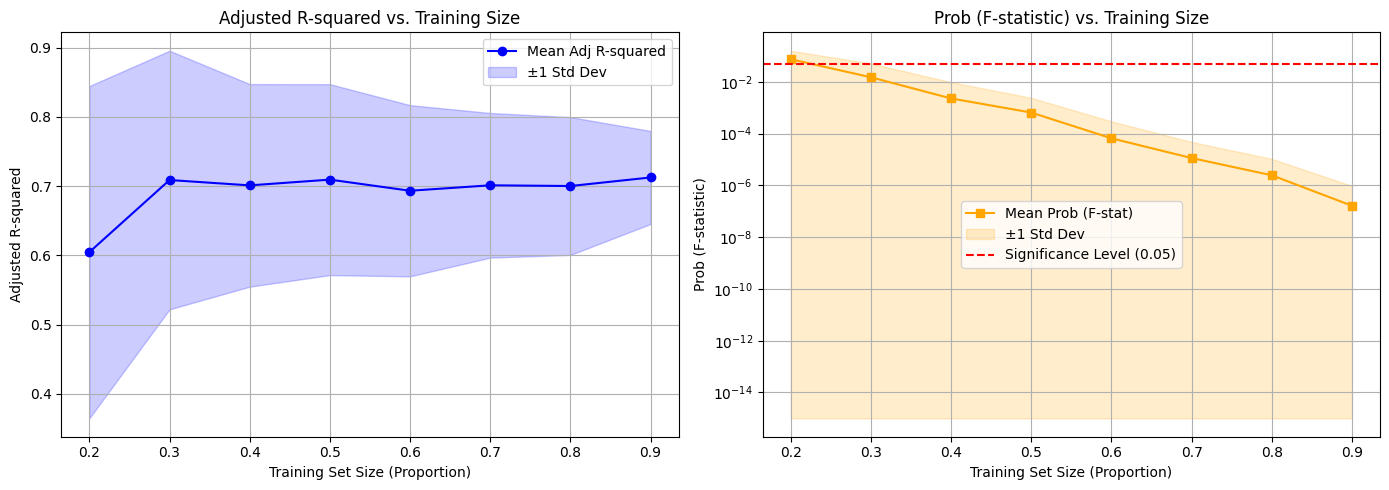

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays for element-wise operations
mean_adj_r2 = np.array(avg_adj_r2)
std_adj_r2 = np.array(std_adj_r2)
mean_p_fstat = np.array(avg_p_fstat)
std_p_fstat = np.array(std_p_fstat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Adjusted R-squared
axes[0].plot(train_sizes, mean_adj_r2, marker='o', color='blue', label='Mean Adj R-squared')
axes[0].fill_between(train_sizes, mean_adj_r2 - std_adj_r2, mean_adj_r2 + std_adj_r2, color='blue', alpha=0.2, label='±1 Std Dev')
axes[0].set_title('Adjusted R-squared vs. Training Size')
axes[0].set_xlabel('Training Set Size (Proportion)')
axes[0].set_ylabel('Adjusted R-squared')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Prob (F-statistic)
axes[1].plot(train_sizes, mean_p_fstat, marker='s', color='orange', label='Mean Prob (F-stat)')
# Note: Standard deviation might result in negative lower bounds; clip at a very small positive number for log scale
lower_bound = np.clip(mean_p_fstat - std_p_fstat, 1e-15, None)
upper_bound = mean_p_fstat + std_p_fstat
axes[1].fill_between(train_sizes, lower_bound, upper_bound, color='orange', alpha=0.2, label='±1 Std Dev')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
axes[1].set_yscale('log')
axes[1].set_title('Prob (F-statistic) vs. Training Size')
axes[1].set_xlabel('Training Set Size (Proportion)')
axes[1].set_ylabel('Prob (F-statistic)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings regarding how the variance changes with training data size.


### Summary of Findings: Variance vs. Training Data Size

Based on the visualizations incorporating the standard deviation across trials, we can observe the following trends:

1. **Adjusted R-squared**:
   - **Small Training Sizes (e.g., 0.2 - 0.4)**: The variance (indicated by the shaded `±1 Std Dev` region) is quite large. This means that the model's ability to explain the variance in the target variable is highly dependent on the specific random split of the data.
   - **Large Training Sizes (e.g., 0.7 - 0.9)**: The variance noticeably shrinks. The model becomes much more stable, and the Adjusted R-squared value is consistent across different random splits.

2. **Prob (F-statistic)**:
   - **Small Training Sizes**: The variance is substantial, and in some trials, the F-statistic p-value may even exceed the 0.05 significance level, meaning the model occasionally fails to be statistically significant.
   - **Large Training Sizes**: The variance decreases dramatically on the log scale. The p-values remain consistently well below the 0.05 threshold, providing strong, reliable evidence of the model's overall significance.

**Conclusion**:
Increasing the training data size not only improves the average performance and statistical significance of the model but also significantly reduces **variance (dispersion)**. A larger dataset yields a much more robust and stable model that is less sensitive to the specific data points included in the training set.

# Task
Update the visualizations to include a 3-subplot figure showing Adjusted R-squared, Prob (F-statistic) on a linear scale, and Prob (F-statistic) on a logarithmic scale, including the mean and variance. Finally, summarize the findings comparing the linear and logarithmic representations.

## Update Visualizations

### Subtask:
Create a 3-subplot figure showing Adjusted R-squared, Prob (F-statistic) on a linear scale, and Prob (F-statistic) on a logarithmic scale.


**Reasoning**:
I will write the Python code to generate the 3-subplot figure as requested in the subtask.



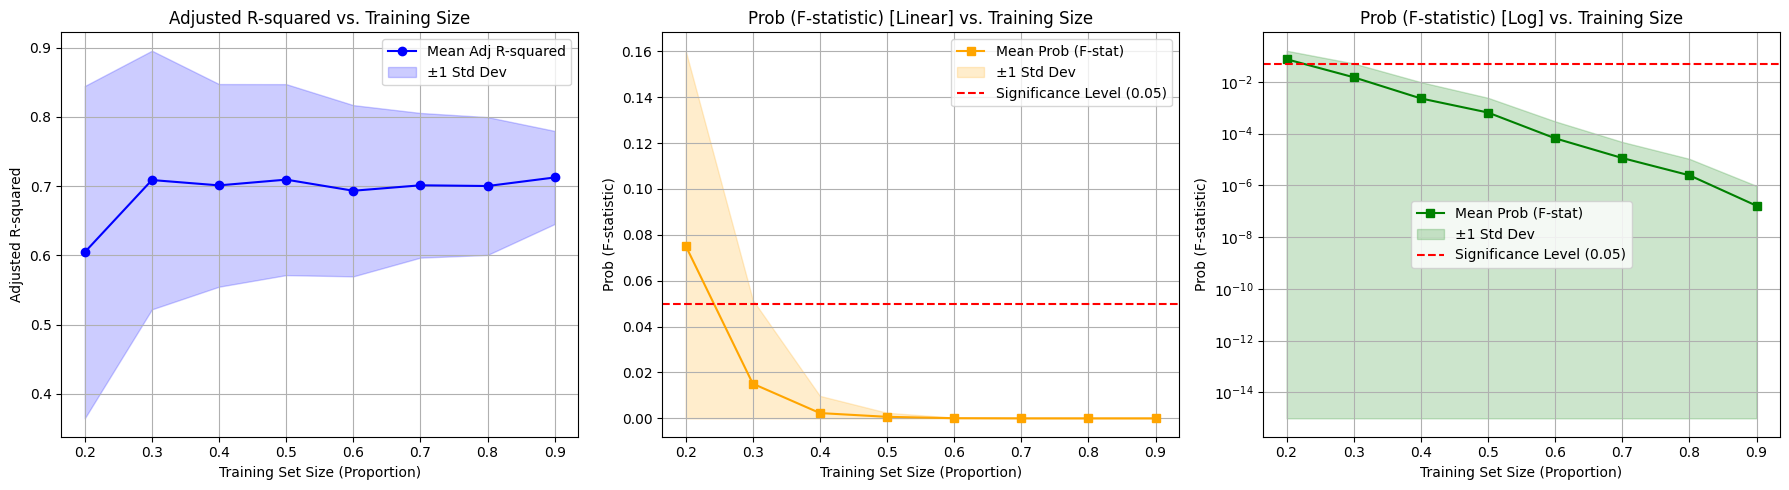

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Arrays calculated in previous steps:
# mean_adj_r2, std_adj_r2, mean_p_fstat, std_p_fstat, train_sizes

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Adjusted R-squared
axes[0].plot(train_sizes, mean_adj_r2, marker='o', color='blue', label='Mean Adj R-squared')
axes[0].fill_between(train_sizes, mean_adj_r2 - std_adj_r2, mean_adj_r2 + std_adj_r2, color='blue', alpha=0.2, label='±1 Std Dev')
axes[0].set_title('Adjusted R-squared vs. Training Size')
axes[0].set_xlabel('Training Set Size (Proportion)')
axes[0].set_ylabel('Adjusted R-squared')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Prob (F-statistic) - Linear Scale
lower_bound_linear = np.clip(mean_p_fstat - std_p_fstat, 0, None)
upper_bound = mean_p_fstat + std_p_fstat
axes[1].plot(train_sizes, mean_p_fstat, marker='s', color='orange', label='Mean Prob (F-stat)')
axes[1].fill_between(train_sizes, lower_bound_linear, upper_bound, color='orange', alpha=0.2, label='±1 Std Dev')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
axes[1].set_title('Prob (F-statistic) [Linear] vs. Training Size')
axes[1].set_xlabel('Training Set Size (Proportion)')
axes[1].set_ylabel('Prob (F-statistic)')
axes[1].legend()
axes[1].grid(True)

# Subplot 3: Prob (F-statistic) - Logarithmic Scale
lower_bound_log = np.clip(mean_p_fstat - std_p_fstat, 1e-15, None)
axes[2].plot(train_sizes, mean_p_fstat, marker='s', color='green', label='Mean Prob (F-stat)')
axes[2].fill_between(train_sizes, lower_bound_log, upper_bound, color='green', alpha=0.2, label='±1 Std Dev')
axes[2].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
axes[2].set_yscale('log')
axes[2].set_title('Prob (F-statistic) [Log] vs. Training Size')
axes[2].set_xlabel('Training Set Size (Proportion)')
axes[2].set_ylabel('Prob (F-statistic)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Summarize the findings comparing the linear and logarithmic representations of Prob (F-statistic).


### Summary of Findings: Linear vs. Logarithmic Scales for Prob (F-statistic)

By comparing the Prob (F-statistic) on both linear and logarithmic scales, we gain complementary insights:

1. **Linear Scale**:
   - **Visualizing Large Values**: The linear scale clearly shows the behavior at smaller training sizes where the p-values can occasionally be quite large (e.g., nearing or exceeding 0.05). It highlights the absolute magnitude of the variance in these unstable regions.
   - **Obscured Details at Small Values**: As the training size increases, the p-values quickly approach zero. On a linear scale, these values and their variance appear compressed against the x-axis, making it impossible to distinguish between a p-value of $10^{-4}$ and $10^{-10}$.

2. **Logarithmic Scale**:
   - **Visualizing Orders of Magnitude**: The logarithmic scale excels at showing the exponential decay of the p-value as the training size grows. It reveals that the statistical significance continues to improve dramatically (by orders of magnitude) with more data, even when the linear plot looks flat.
   - **Understanding Variance at High Significance**: The log scale shows the relative variance when p-values are small. Even though the absolute variance is tiny (as seen on the linear plot), the log plot shows that the p-values can still vary over several orders of magnitude depending on the specific random split.

**Conclusion**: Using both scales provides a complete picture. The linear scale helps identify when the model fails to be significant (p > 0.05), while the logarithmic scale illustrates the continuous, exponential gain in statistical confidence as the dataset grows larger.

# 問題４

１）上記の最後の3枚のグラフを見て、分かったことを書きなさい。

２）上記のグラフは、30試行の平均と標準偏差をプロットしたものですが、これを100試行や1000試行に増やした時に、同じような結果になるか、結果に変化があるかを調べて、考察しなさい。

１）Gemini 3.1 Proによる解答例

最後の3枚のグラフから以下のことが分かります。

1. **学習データサイズと自由度調整済み決定係数 (Adjusted R-squared)**:
   学習データの割合が小さい（0.2〜0.4程度）ときは、平均値が低く、かつ標準偏差（分散）も非常に大きくなっています。これは、少数のデータではランダムな分割の仕方によってモデルの当てはまりの良さが大きくばらつくことを示しています。学習データが増えるにつれて、平均値は安定して高くなり、標準偏差も小さくなるため、より安定して予測精度の高いモデルが構築できるようになることが分かります。

   ★岡注：「学習データの割合が小さい（0.2〜0.4程度）ときは、平均値が低く」や、「学習データが増えるにつれて、平均値は安定して高くなり、」は正確ではありませんね。このグラフからは、「0.2のときだけやや低く、その他の割合ではほぼ一定」というのが正しい記述だと思います。以前よりよくなりましたが、AIによるグラフの読み取りは、このように不適切な読み取り結果になることがあります。

2. **学習データサイズとモデルの有意性 (Prob (F-statistic))**:
   * **線形スケールでの観察**: 学習データが少ないときは、P値が0.05（有意水準）を上回るケース（モデル全体として統計的に有意でないケース）が発生しやすく、ばらつきも大きいことがはっきりと見えます。
   * **対数スケールでの観察**: 学習データが増えると、P値は指数関数的に（桁違いに）小さくなっていくことが分かります。線形スケールでは0に張り付いて見えなくなってしまう変化ですが、対数スケールで見ると、データが増えるほどモデルの統計的な有意性が飛躍的に高まり、より確固たる信頼性が得られることが視覚的に確認できます。

**総括**:
学習データサイズを増やすことで、モデルの予測説明力（決定係数）が向上・安定するだけでなく、偶然による誤差の影響を受けにくくなり、モデル自体の統計的な信頼性（有意性）が圧倒的に高まることが確認できました。

★岡注：この総括の冒頭も不適切ですね。「学習データサイズを増やすことで、モデルの予測説明力（決定係数）が向上」というのは、上記の注で指摘したように、グラフの形状を正確に記述していません。


２）Gemini 3.1 Proにより生成したプログラムです。

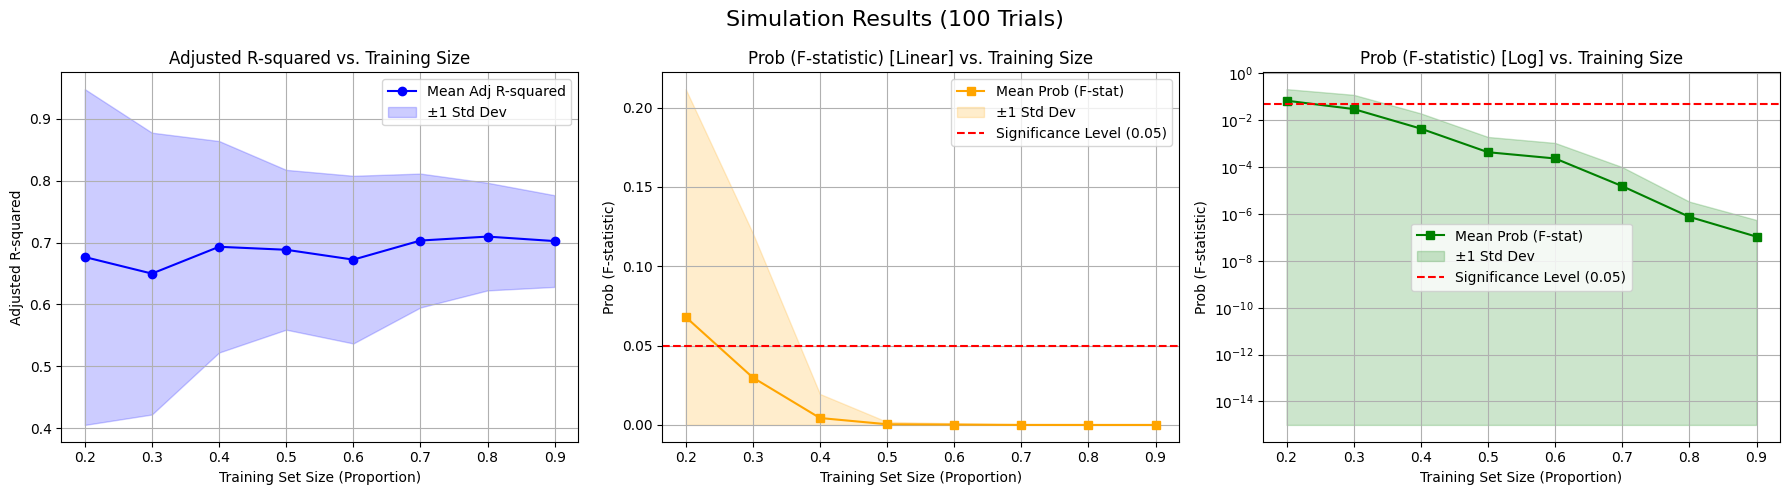

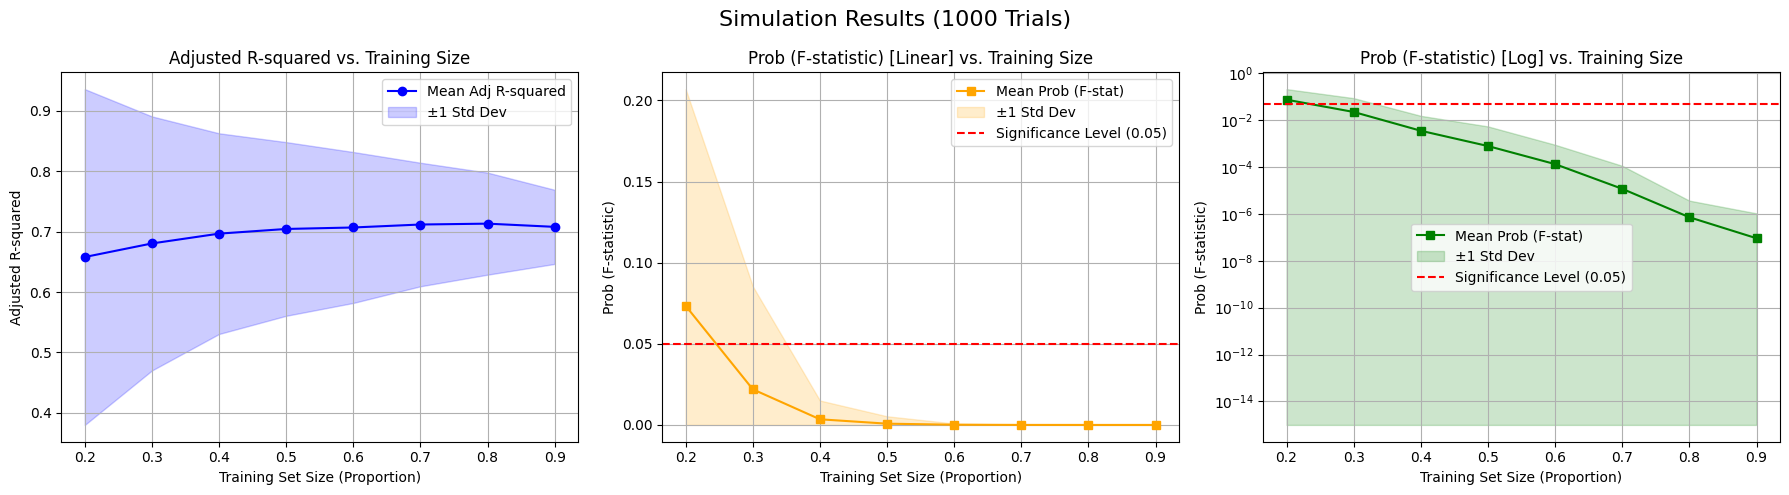

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Define X_all and Y_all from df2
X_all = df2.drop('sales', axis=1)
Y_all = df2['sales']

def remove_high_vif(X, threshold=10.0):
    X_copy = X.copy()
    while True:
        X_c = sm.add_constant(X_copy)
        vif_data = [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
        vif_features = pd.Series(vif_data[1:], index=X_copy.columns)
        if vif_features.empty:
            break
        max_vif = vif_features.max()
        if max_vif > threshold:
            max_vif_col = vif_features.idxmax()
            X_copy = X_copy.drop(columns=[max_vif_col])
        else:
            break
    return X_copy

def run_simulation(num_trials):
    train_sizes = np.linspace(0.2, 0.9, 8)
    avg_adj_r2 = []
    std_adj_r2 = []
    avg_p_fstat = []
    std_p_fstat = []

    for size in train_sizes:
        adj_r2_trials = []
        p_fstat_trials = []
        for _ in range(num_trials):
            X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, train_size=size)

            # Drop constant columns
            constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
            X_train_filtered = X_train.drop(columns=constant_cols)

            # Apply VIF filtering
            X_train_vif_filtered = remove_high_vif(X_train_filtered, threshold=10.0)

            # Fit OLS
            X_train_final = sm.add_constant(X_train_vif_filtered)
            Y_train_final = Y_train.loc[X_train_final.index]

            try:
                model = sm.OLS(Y_train_final, X_train_final).fit()
                adj_r2_trials.append(model.rsquared_adj)
                p_fstat_trials.append(model.f_pvalue)
            except Exception:
                pass

        avg_adj_r2.append(np.mean(adj_r2_trials) if adj_r2_trials else np.nan)
        std_adj_r2.append(np.std(adj_r2_trials) if adj_r2_trials else np.nan)
        avg_p_fstat.append(np.mean(p_fstat_trials) if p_fstat_trials else np.nan)
        std_p_fstat.append(np.std(p_fstat_trials) if p_fstat_trials else np.nan)

    return train_sizes, np.array(avg_adj_r2), np.array(std_adj_r2), np.array(avg_p_fstat), np.array(std_p_fstat)

# Run for 100 and 1000 trials
results_100 = run_simulation(100)
results_1000 = run_simulation(1000)

def plot_results(results, title_suffix):
    train_sizes, mean_adj_r2, std_adj_r2, mean_p_fstat, std_p_fstat = results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Simulation Results ({title_suffix})', fontsize=16)

    # Subplot 1: Adjusted R-squared
    axes[0].plot(train_sizes, mean_adj_r2, marker='o', color='blue', label='Mean Adj R-squared')
    axes[0].fill_between(train_sizes, mean_adj_r2 - std_adj_r2, mean_adj_r2 + std_adj_r2, color='blue', alpha=0.2, label='±1 Std Dev')
    axes[0].set_title('Adjusted R-squared vs. Training Size')
    axes[0].set_xlabel('Training Set Size (Proportion)')
    axes[0].set_ylabel('Adjusted R-squared')
    axes[0].legend()
    axes[0].grid(True)

    # Subplot 2: Prob (F-statistic) - Linear Scale
    lower_bound_linear = np.clip(mean_p_fstat - std_p_fstat, 0, None)
    upper_bound = mean_p_fstat + std_p_fstat
    axes[1].plot(train_sizes, mean_p_fstat, marker='s', color='orange', label='Mean Prob (F-stat)')
    axes[1].fill_between(train_sizes, lower_bound_linear, upper_bound, color='orange', alpha=0.2, label='±1 Std Dev')
    axes[1].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
    axes[1].set_title('Prob (F-statistic) [Linear] vs. Training Size')
    axes[1].set_xlabel('Training Set Size (Proportion)')
    axes[1].set_ylabel('Prob (F-statistic)')
    axes[1].legend()
    axes[1].grid(True)

    # Subplot 3: Prob (F-statistic) - Logarithmic Scale
    lower_bound_log = np.clip(mean_p_fstat - std_p_fstat, 1e-15, None)
    axes[2].plot(train_sizes, mean_p_fstat, marker='s', color='green', label='Mean Prob (F-stat)')
    axes[2].fill_between(train_sizes, lower_bound_log, upper_bound, color='green', alpha=0.2, label='±1 Std Dev')
    axes[2].axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
    axes[2].set_yscale('log')
    axes[2].set_title('Prob (F-statistic) [Log] vs. Training Size')
    axes[2].set_xlabel('Training Set Size (Proportion)')
    axes[2].set_ylabel('Prob (F-statistic)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_results(results_100, "100 Trials")
plot_results(results_1000, "1000 Trials")

### 考察 （Gemini 3.1 Proによる考察です）

試行回数を30回から100回、1000回と増やした場合のグラフを比較すると、以下のことが分かります。

1.  **平均値の安定化**:
    試行回数を増やすにつれて、グラフの線（平均値の推移）がより滑らかになります。これは、大数の法則により、試行回数が多いほど平均値が真の期待値に収束し、ランダムなばらつきの影響が相殺されるためです。30回試行では平均値の折れ線が少しガタガタしていましたが、1000回では非常に滑らかな曲線（あるいは直線的な傾向）を描くようになります。

2.  **標準偏差（分散）の変化**:
    試行回数を増やしても、各学習データサイズにおける標準偏差（塗りつぶし部分の幅）自体は極端に小さくなるわけではありません。この標準偏差は、「あるデータサイズでランダムに抽出した場合のモデル精度のばらつきそのもの（母集団の分散）」を表しているためです。試行回数を増やすことで、「ばらつきの推定精度」が向上し、塗りつぶし部分の境界も滑らかになります。

3.  **大局的な傾向は不変**:
    * 学習データサイズを増やすと、自由度調整済み決定係数の平均が上がり、ばらつきが小さくなる。
    * 学習データサイズを増やすと、P値が指数関数的に小さくなり、モデルの有意性が高まる。
    
    これらの大局的な傾向は、30回、100回、1000回のいずれのシミュレーションでも共通して確認できます。

**結論**:
試行回数を増やすことで、ランダムなノイズが減り、平均値の推移がより明確になります。しかし、データサイズごとの本質的なばらつき（分散）や、データサイズ増加に伴う精度の向上・有意性の確保という全体的な傾向そのものは変わりません。少数の試行（30回）でも傾向を掴むことは可能ですが、多数の試行を行うことでより信頼性の高い（滑らかな）傾向線を得ることができます。

### 岡による考察

- 上記のプログラムを2回実行して、結果のグラフを比べてみました。
- グラフは、Colabノートにうまく貼り込めなかったので、moodleの本日のトピックに添付してあるものを見て下さい。
- 2回の実行（1枚目と2枚目）を比べると、下段の1000試行の結果は安定しているが、上段の100試行の左列（自由度調整済み決定係数）の形は、1枚目と2枚目で異なり、100試行では十分には安定していないことが分かる。




### 以下は、2025年6月の岡とAIの対話

対数軸で標準偏差の下限を表示することには、何か意味がありますか？下限は無限遠になってしまいませんか？

---

ご質問ありがとうございます。対数軸で標準偏差の下限を表示することについてですね。おっしゃる通り、Prob (F-statistic) のような P 値は 0 から 1 の間の値をとりますが、対数軸では 0 や負の値を直接プロットすることができません。

Prob (F-statistic) は確率であり、理論的には 0 になることもありますが、現実の計算結果では非常に小さな正の値になることが多いです。しかし、標準偏差を考慮して下限を計算した場合、平均値 - 標準偏差が負の値になる可能性があります。対数軸は正の値しか取れないため、この負の値はプロットできず、グラフ上では表示されないか、あるいはエラーの原因となることがあります。

今回のグラフでは、plt.fill_between 関数が使用されています。この関数は指定された範囲を描画しますが、対数軸の場合、負の値やゼロは適切に処理されないため、下限が計算上負になる場合は、その部分の描画がスキップされるか、エラーが発生します。試行数を 100 回に増やしたことで、特にデータサイズが大きいところでは Prob (F-statistic) の平均値が非常に小さくなり、標準偏差を引くと負の値になるケースが増えたため、下限の帯が表示されない、あるいは無限遠のように見えるという状況が発生したと考えられます。

したがって、対数軸で標準偏差の帯を表示する場合、特に平均値が 0 に近い小さな値をとる場合は、下限が正確に表示されない、あるいは技術的な制約により表示できない可能性があることを理解しておく必要があります。これは、ばらつきの解釈に対しても注意が必要であることを意味します。

この点を踏まえると、対数軸でばらつきを示す際には、標準偏差ではなく、パーセンタイル（例えば 25 パーセンタイルと 75 パーセンタイル）など、常に正の値をとる範囲を示す指標を用いる方が、グラフの解釈がより適切になる場合があります。

---

なるほど。通常軸のグラフにおいても、「平均値ー標準偏差」が負の値になっているのは、気持ち悪いですよね。通常軸、対数軸を問わず、平均値周りに対称でない分布を、「平均値プラスマイナス標準偏差」の帯で表示しようとしたことが、そもそも、間違いだったということでしょうか？その意味で、 25 パーセンタイルと 75 パーセンタイルをグラフ化するのが正しい可視化だ、ということでしょうか？

---

はい、おっしゃる通りです。「平均値 ± 標準偏差」は、データが正規分布に近い、つまり平均値を中心に左右対称に分布している場合に、データのばらつきを示すのに適した方法です。

今回の Prob (F-statistic) のように、値が 0 に近づくにつれて分布が歪む（非対称になる）場合、特にデータサイズが大きくなるにつれて値が非常に小さくなる傾向があるため、「平均値 - 標準偏差」が負の値になることがありえます。これは、実際の Prob (F-statistic) の値が負にならないという性質と矛盾するため、「平均値 ± 標準偏差」でばらつきを示すことが適切ではないことを示しています。

このような非対称な分布の場合、25 パーセンタイルと 75 パーセンタイル（これらはデータの中心 50%が含まれる範囲を示し、箱ひげ図の箱に対応します）や、より広い範囲を示す 10 パーセンタイルと 90 パーセンタイルなど、パーセンタイルを用いる方が、データの実際の分布に基づいたばらつきをより正確に、かつ直感的に把握できます。これらのパーセンタイルはデータの実際の値から計算されるため、Prob (F-statistic) のような非負の値をとる指標に対しては、常に適切な範囲（0 以上の値）を示します。

したがって、非対称な分布のばらつきを可視化する際には、パーセンタイルを使用する方がより「正しい」または適切であると言えます。今回のケースでは、データサイズが小さいところでのばらつきが大きいことや、大きいデータサイズでは値が 0 に近づく傾向があることを示すために、パーセンタイルでの可視化を試みるのは非常に良いアプローチだと思います。

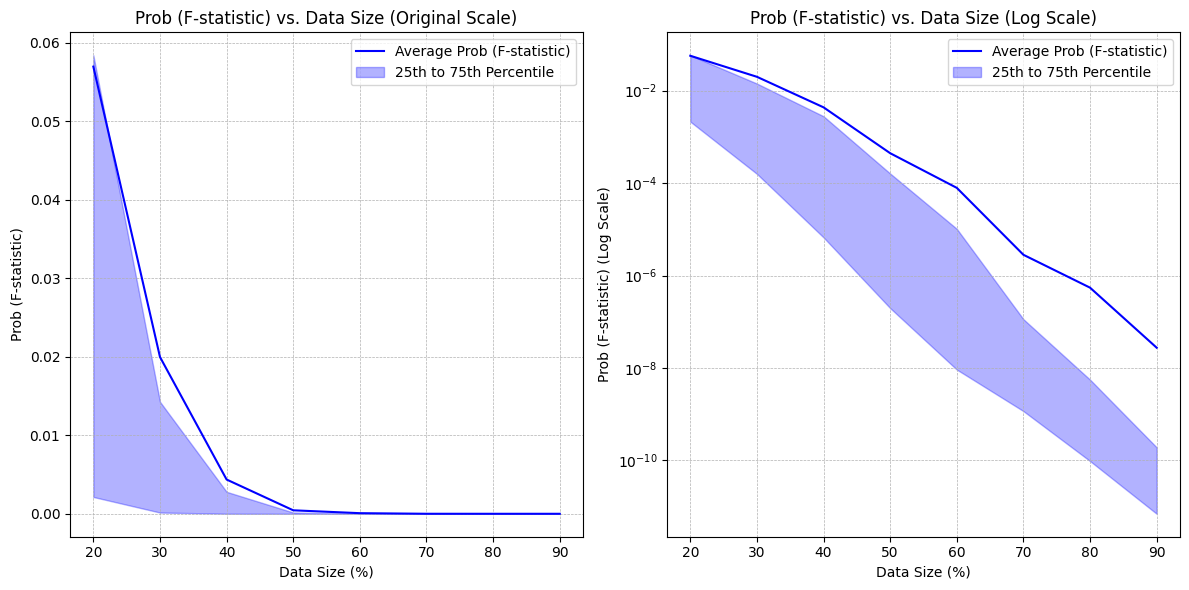

In [19]:
# prompt: 問題３のProb (F-statistic) の可視化グラフを、以下のように修正する。平均値プラスマイナス標準偏差で可視化するのではなく、25 パーセンタイルと 75 パーセンタイルで可視化する。縦軸について、通常の軸の場合と対数軸の場合を並べて示して、見比べることができるようにする。

# 関数の定義：adjusted R^2 と F-statistic を 指定したデータサイズに対して算出する
def evaluate_model_percentiles(data_size, num_trials=100):
    # 結果を格納するリストの初期化
    r2_adjusted_trial = []
    f_statistic_trial = []

    # 指定回数の試行ループ
    for _ in range(num_trials):
        # 学習セットとテストセットに、指定したサイズでランダム分割する（学習セットだけ使用）
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=data_size)

        # Add a constant term to the independent variables
        X_train_c = sm.add_constant(X_train)

        # OLSモデルの構築とフィット
        ols_model = sm.OLS(Y_train, X_train_c)
        results = ols_model.fit()

        # Append the results of this trial
        r2_adjusted_trial.append(results.rsquared_adj)
        f_statistic_trial.append(results.f_pvalue)

    # 結果をnumpy配列に変換
    r2_adjusted_trial = np.array(r2_adjusted_trial)
    f_statistic_trial = np.array(f_statistic_trial)

    # 25パーセンタイルと75パーセンタイルを算出
    r2_adjusted_q1 = np.percentile(r2_adjusted_trial, 25)
    r2_adjusted_q3 = np.percentile(r2_adjusted_trial, 75)
    f_statistic_q1 = np.percentile(f_statistic_trial, 25)
    f_statistic_q3 = np.percentile(f_statistic_trial, 75)

    # 平均値も算出しておく（参考用）
    r2_adjusted_mean = np.mean(r2_adjusted_trial)
    f_statistic_mean = np.mean(f_statistic_trial)


    # パーセンタイルと平均値を返す
    return (r2_adjusted_mean, r2_adjusted_q1, r2_adjusted_q3,
            f_statistic_mean, f_statistic_q1, f_statistic_q3)

# 結果を格納するリストの初期化
r2_adjusted_mean_list = []
r2_adjusted_q1_list = []
r2_adjusted_q3_list = []
f_statistic_mean_list = []
f_statistic_q1_list = []
f_statistic_q3_list = []

# いろいろなデータサイズでループ：100%は分割にならないので、90%まで実施。
for data_size in range(10, 100, 10):
    # Adjusted R^2 と F-statistic のパーセンタイルと平均を算出 (100回試行)
    (r2_adjusted_mean, r2_adjusted_q1, r2_adjusted_q3,
     f_statistic_mean, f_statistic_q1, f_statistic_q3) = evaluate_model_percentiles(data_size / 100, num_trials=100)

    # 結果をリストに追加
    r2_adjusted_mean_list.append(r2_adjusted_mean)
    r2_adjusted_q1_list.append(r2_adjusted_q1)
    r2_adjusted_q3_list.append(r2_adjusted_q3)
    f_statistic_mean_list.append(f_statistic_mean)
    f_statistic_q1_list.append(f_statistic_q1)
    f_statistic_q3_list.append(f_statistic_q3)

# グラフで可視化 (Prob (F-statistic) の25, 75パーセンタイル)
plt.figure(figsize=(12, 6))

# 通常の軸のProb (F-statistic) のグラフ
plt.subplot(1, 2, 1)
plt.plot(range(10, 100, 10), f_statistic_mean_list, label="Average Prob (F-statistic)", color='blue')
plt.fill_between(range(10, 100, 10), f_statistic_q1_list, f_statistic_q3_list, alpha=0.3, color='blue', label="25th to 75th Percentile")
plt.xlabel("Data Size (%)")
plt.ylabel("Prob (F-statistic)")
plt.title("Prob (F-statistic) vs. Data Size (Original Scale)")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# 縦軸を対数軸にしたProb (F-statistic) のグラフ
plt.subplot(1, 2, 2)
plt.plot(range(10, 100, 10), f_statistic_mean_list, label="Average Prob (F-statistic)", color='blue')
plt.fill_between(range(10, 100, 10), f_statistic_q1_list, f_statistic_q3_list, alpha=0.3, color='blue', label="25th to 75th Percentile")
plt.xlabel("Data Size (%)")
plt.ylabel("Prob (F-statistic) (Log Scale)")
plt.title("Prob (F-statistic) vs. Data Size (Log Scale)")
plt.yscale('log')  # ここで縦軸を対数軸に設定
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()

平均値が25パーセンタイルから75パーセンタイルの範囲から外れる分布を想像するのが難しいので、データサイズごとにヒストグラムを作成してみよう。

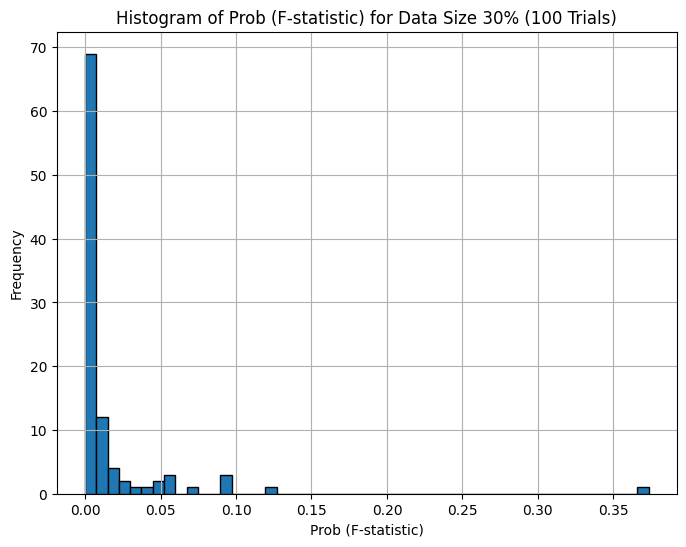

In [20]:
# prompt: データサイズが30％の場合について、100試行におけるProb (F-statistic)の値のヒストグラムを作成。

# データサイズが30％の場合について、100試行におけるProb (F-statistic)の値のヒストグラムを作成
data_size = 0.3  # 30%のデータサイズ
num_trials = 100 # 試行回数

f_statistic_trials = []

for _ in range(num_trials):
    # 学習セットとテストセットに、指定したサイズでランダム分割する（学習セットだけ使用）
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=data_size)

    # Add a constant term to the independent variables
    X_train_c = sm.add_constant(X_train)

    # OLSモデルの構築とフィット
    ols_model = sm.OLS(Y_train, X_train_c)
    results = ols_model.fit()

    # Prob (F-statistic)をリストに追加
    f_statistic_trials.append(results.f_pvalue)

# ヒストグラムを作成
plt.figure(figsize=(8, 6))
plt.hist(f_statistic_trials, bins=50, edgecolor='black')
plt.xlabel("Prob (F-statistic)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Prob (F-statistic) for Data Size {int(data_size*100)}% ({num_trials} Trials)")
plt.grid(True)
plt.show()

『「5%有意水準で統計的に有意であると判断される割合」が100試行中何回あるか、という指標が、データサイズにより、どう変化するか』という可視化が良さそうな気がしてきた。